This cell imports all necessary packages

In [1]:
# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import copy
import seaborn as sns

# Gensim imports
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import HdpModel

# Sklearn imports
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD, PCA
from sklearn.manifold import TSNE, MDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

This code is intended for topic analysis and clustering on metagenomic datasets driven by Latent Dirichlet Allocation (LDA).

In particular, it takes collections of samples with corresponding OTU counts (for example - from 16S rRNA sequencing) and metadata.

It takes as input the following information organized as specified.
- OTU Count Table - Sample IDs in column 0, OTU frequency counts in subsequent columns.

    _Note: We do not recommend any sort of prescaling or prevalence/abundance filtering on the data. LDA is built to take "bag-of-words" style input._
- Sample Metadata - Sample IDs in column 0, relevant data in subsequent columns. 

Optionally, if you want to run similar processing at various taxonomic levels:
- Taxonomy Table - OTUs in column 0, taxonomic classifications (Order, Family, Genus, etc.) in subsequent columns.

Alternatively, you can just use a table that has counts of, i.e., Family frequency in place of the OTU count table.

Below is the code to generate the LDA model. LDA requires a pre-picked number of topics, so we first use HDP to generate an appropriate number of topics for the dataset.

There are a couple useful parameters to keep in mind:
> threshold:
>>HDP generates a huge number of topics. We prune all topics below a certain relevance threshold to get a topic number for LDA. Toggling this will give more generous or conservative topic counts.

>LDA_passes:
>>how many passes over the data LDA makes. A higher number means sounder analysis but longer runtime.

LDA priors:

LDA is a Bayesian inference technique. It makes assumptions about how the data is "generated" based on choice of $\alpha$ and $\eta$.

>$\alpha$ controls topics per document. A small $\alpha$ means spikier distributions, documents concentrate probability on fewer topics. A large $\alpha$ corresponds to a smoother distribution.

>$\eta$ controls words per topic. Similarly, a small $\eta$ means spikier topics focused on fewer words.

In general, small $\alpha$ and $\eta$ are preferable, leading to sparser, more interpretable topics. However, making these parameters too small increases risk of overfitting. The code lets Gensim automatically generate priors appropriate to the dataset, but this can be replaced by specificying a symmetric distribution or even manually choosing a distribution vector.

Generating model may take a few minutes. Saving the LDA output can save time in the future.

In [ ]:
##set variables here (threshold, LDA, priors)
##set directory paths (inputs / results)

In [32]:
def generateModel(file_name, threshold = 0.02, LDA_passes = 10):
    # load dataset
    df = pd.read_csv(file_name)
    df = df.drop(df.columns[0], axis=1)  # drop index column if present

    # convert frequency to bag-of-words
    texts = []
    for row in df.itertuples(index=False):
        doc = []
        for word, count in zip(df.columns, row):
            doc.extend([word] * int(count))
        texts.append(doc)

    # construct dictionary and corpus
    dictionary = Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # get # topics from HDP
    hdp = HdpModel(corpus=corpus, id2word=dictionary)

    topic_usage = np.zeros(hdp.get_topics().shape[0])
    for doc in corpus:
        doc_topics = hdp[doc]  # list of (topic_id, prob)
        for topic_id, prob in doc_topics:
            topic_usage[topic_id] += prob
    topic_usage /= len(corpus) # gives the average "probability" of a topic across all documents

    topic_count = np.sum(topic_usage > threshold) # counts number of useful topics
    print(f"HDP inferred ~{topic_count} topics")

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=topic_count,
        random_state=0,
        passes=LDA_passes,
        alpha="auto", eta="auto" # toggle as desired
    )

    return lda, df, dictionary, corpus

The following function gives a breakdown of topics by their most important terms at the desired taxonomic level. For example, you might run LDA at the OTU level, but want output at the family level.

In [3]:
def topicBreakdown(model, dictionary, taxonomy_file_name, input_taxonomy, output_taxonomy, output_path, term_num = 10):
    taxonomy = pd.read_csv(taxonomy_file_name)
    result = ''

    # create a map between your input and output levels for faster lookup
    taxonomy_map = dict(zip(taxonomy[input_taxonomy], taxonomy[output_taxonomy]))
    
    # get heaviest terms in each topic
    topic_ids = range(model.num_topics)
    get_terms = lambda i: model.get_topic_terms(i, topn=term_num)

    # iterate over topics
    for i in topic_ids:
        result += f"Topic {i}: "
        for term_id, weight in get_terms(i):
            word = dictionary[term_id]

            # match taxonomy
            result += str(taxonomy_map.get(word, "Not Found")) + ' '
        result += "\n"

    # save and output results
    output_filename = output_path + "topic_breakdown.txt"
    with open(output_filename, 'w') as f:
        f.write(result)

    print(f"Topic breakdown saved to {output_filename}")
    print(result)

This method gives a bubble plot of importance of terms by topic. Again, it can output at any taxonomic level for interpretability. Set n to the desired number of topics displayed.

In [ ]:
def topicDistPlot(model, dictionary, taxonomy_file_name, input_taxonomy, output_taxonomy, output_path, n = 10):
    taxonomy = pd.read_csv(taxonomy_file_name)
    topic_data = []

    taxonomy_map = dict(zip(taxonomy[input_taxonomy], taxonomy[output_taxonomy]))

    # LDA
    topic_ids = range(model.num_topics)
    get_terms = lambda i: model.get_topic_terms(i, topn=len(dictionary))

    # collect topic data
    for i in topic_ids:
        top_terms = get_terms(i)

        for term_id, importance in top_terms:
            word = str(dictionary[term_id]).strip() if term_id is not None else None

            # lookup taxonomy
            family_name = taxonomy_map.get(word, "Not Found") if word else "Not Found"

            topic_data.append({
                "Topic": i,
                output_taxonomy: family_name,
                "Importance": importance
            })

    
    print("topic_data sample:", topic_data[:5])
    print("Number of entries:", len(topic_data))

    # convert to dataframe
    df_plot = pd.DataFrame(topic_data)

    top_families = (
        df_plot.groupby(output_taxonomy)["Importance"]
        .sum()
        .sort_values(ascending=False)
        .head(n)
        .index
    )

    df_plot = df_plot[df_plot[output_taxonomy].isin(top_families)]

    # aggregate importance values at desired level
    df_agg = df_plot.groupby(["Topic", output_taxonomy], as_index=False)["Importance"].sum()

    # bubble plot
    plt.figure(figsize=(10, 6))
    bubble = sns.scatterplot(
        data=df_agg,
        x="Topic",
        y=output_taxonomy,
        size="Importance",
        hue="Importance",
        sizes=(20, 1000),
        palette="viridis",
        edgecolor="black",
        alpha=0.7
    )

    plt.xticks(rotation=45)
    plt.xlabel("Topic")
    plt.ylabel(output_taxonomy)
    plt.title(f"Bubble Plot of {output_taxonomy} per Topic")
    plt.legend(title="Importance")
    plt.tight_layout()

    # save and show
    output_filename = output_path + "topic_dist_plot.png"
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"Bubble plot saved to {output_filename}")

Ideally, the topics yielded by LDA should align with the metadata over the samples. The following code plots strongest topic per sample against the actual categorization of the sample in the metadata. Assign relevant_metadata to the name of the column of interest in the metadata.

In [48]:
def metaPlot(model, corpus, metadata_file, relevant_metadata, output_path):

    body_sites = pd.read_csv(metadata_file)
    
    # detect topic count
    num_topics = model.num_topics  # LDA

    # find topic distributions for each document
    topic_distributions = []
    for doc_bow in corpus:
        doc_topics = model.get_document_topics(doc_bow, minimum_probability=0)
        # convert to full vector (pad to num_topics)
        topic_vector = np.zeros(num_topics)
        for topic_id, prob in doc_topics:
            if topic_id < num_topics:  # safeguard
                topic_vector[topic_id] = prob
        topic_distributions.append(topic_vector)

    topic_distributions = np.array(topic_distributions)

    # assign strongest topic
    strongest_topic_indices = topic_distributions.argmax(axis=1)
    body_sites['Strongest_Topic'] = strongest_topic_indices

    # find topic counts by site
    topic_counts_by_site = body_sites.groupby([relevant_metadata, 'Strongest_Topic']).size().reset_index(name="Count")

    # output a table of counts by site
    topic_counts_table = body_sites.groupby(['HMP_BODY_SITE', 'Strongest_Topic']).size().unstack(fill_value=0)
    print(topic_counts_table)

    table_filename = output_path + "metadata_table.csv"
    topic_counts_table.to_csv(table_filename, index=False)
    print(f"Table saved to {table_filename}")

    # bubble plot
    plt.figure(figsize=(12, 7))
    bubble = sns.scatterplot(
        data=topic_counts_by_site,
        x="Strongest_Topic",
        y=relevant_metadata,
        size="Count",
        hue="Count",
        sizes=(20, 1000),
        palette="viridis",
        edgecolor="black",
        alpha=0.7
    )

    plt.xticks(rotation=45)
    plt.xlabel("Strongest Topic")
    plt.ylabel(relevant_metadata)
    plt.title(f"Bubble Plot of Topic Assignments by {relevant_metadata}")
    plt.legend(title="Sample Count", loc='upper right')
    plt.tight_layout()

    output_filename = output_path + "metadata_plot.png"
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"Bubble plot saved to {output_filename}")

Function to find optimal component number for each taxonomic level by perplexity, returning a graph and a table at that level.

Example on our dataset (HMP OTU counts)

In [41]:
file_name = "../metag_topic_modeling/data_sets/HMP_V13_OTU_counts.csv"
output_path = "../metag_topic_modeling/results3/"
taxonomy_file = "../metag_topic_modeling/data_sets/HMP_V13_taxonomy_fix.csv"
metadata = "../metag_topic_modeling/data_sets/HMP_V13_participant_data.csv"

In [33]:
lda, df, dictionary, corpus = generateModel(file_name)

HDP inferred ~13 topics


In [34]:
topicBreakdown(lda, dictionary, taxonomy_file, "OTU_ID", "FAMILY", output_path)

Topic breakdown saved to ../metag_topic_modeling/results3/topic_breakdown.txt
Topic 0: Campylobacteraceae Veillonellaceae Veillonellaceae Veillonellaceae Lachnospiraceae Veillonellaceae nan Prevotellaceae Prevotellaceae Veillonellaceae 
Topic 1: Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobacillaceae 
Topic 2: Burkholderiaceae Streptococcaceae Neisseriaceae Streptococcaceae Neisseriaceae Campylobacteraceae Flavobacteriaceae Burkholderiaceae Flavobacteriaceae Neisseriaceae 
Topic 3: Staphylococcaceae nan Staphylococcaceae Staphylococcaceae Moraxellaceae Staphylococcaceae Propionibacteriaceae Comamonadaceae Staphylococcaceae Moraxellaceae 
Topic 4: Streptococcaceae Streptococcaceae Streptococcaceae Gemellaceae Streptococcaceae Streptococcaceae Streptococcaceae Streptococcaceae Carnobacteriaceae Gemellaceae 
Topic 5: Lactobacillaceae Lactobacillaceae Lactobacillaceae Lactobaci

topic_data sample: [{'Topic': 0, 'FAMILY': 'Campylobacteraceae', 'Importance': 0.046353023}, {'Topic': 0, 'FAMILY': 'Veillonellaceae', 'Importance': 0.018220149}, {'Topic': 0, 'FAMILY': 'Veillonellaceae', 'Importance': 0.017463872}, {'Topic': 0, 'FAMILY': 'Veillonellaceae', 'Importance': 0.0122940885}, {'Topic': 0, 'FAMILY': 'Lachnospiraceae', 'Importance': 0.011993452}]
Number of entries: 559728


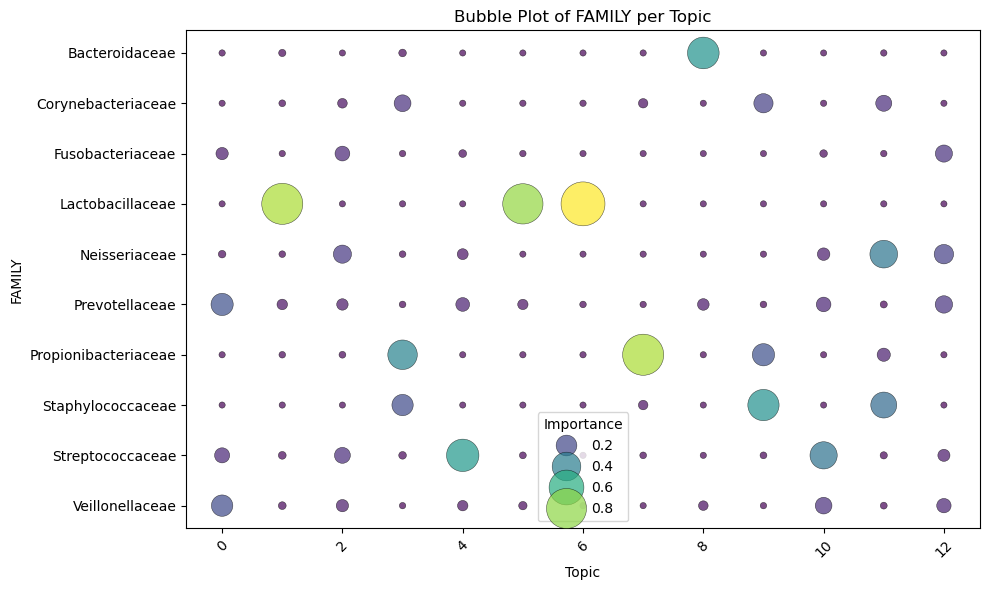

Bubble plot saved to ../metag_topic_modeling/results3/topic_dist_plot.png


In [39]:
topicDistPlot(lda, dictionary, taxonomy_file, "OTU_ID", "FAMILY", output_path)

Strongest_Topic          0   1    2   3    4    5    6    7    8    9    10  \
HMP_BODY_SITE                                                                 
Airways                   0   0    1  16    0    1    0   11    1  113    0   
Gastrointestinal Tract    0   0    0   0    1    0    0    0  186    0    0   
Oral                    263   0  408   1  399    0    0    2    1    0  250   
Skin                      0   0    2  83    2    1    2  391   11  157    0   
Urogenital Tract          0  37    1   0    2  110  114    0    0    0    0   

Strongest_Topic         11   12  
HMP_BODY_SITE                    
Airways                 17    1  
Gastrointestinal Tract   0    0  
Oral                     0  298  
Skin                    13    2  
Urogenital Tract         0    0  
Table saved to ../metag_topic_modeling/results3/metadata_table.csv


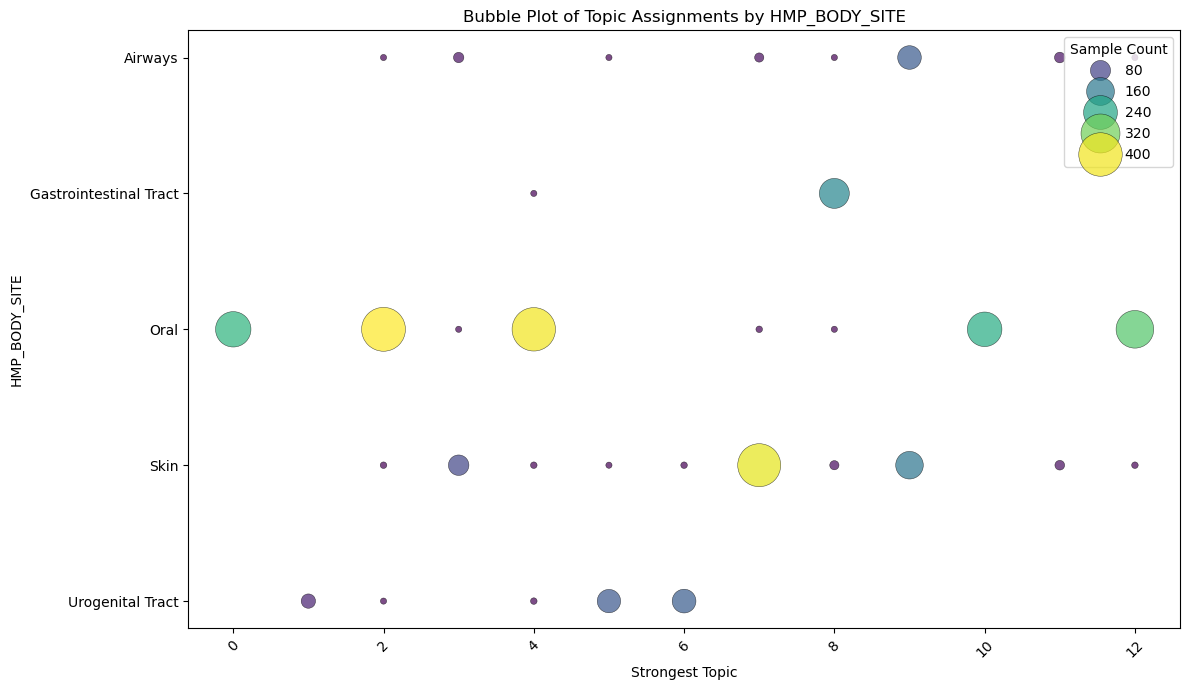

Bubble plot saved to ../metag_topic_modeling/results3/metadata_plot.png


In [49]:
metaPlot(lda, corpus, metadata, "HMP_BODY_SITE", output_path)

Functionality I'd like to add:
- Run over a specific subset of data, i.e. mouth data
- Run LDA at any taxonomic level
- Plot LDA topics over some dimension reduced (PCA, tSNE) scatterplot

Warnings for plots - what to look for (less overlap)

Intro
- Brief technical explanation of LDA
- Explain why it applies to microbiome (why are bayesian assumptions reasonable and match our physical model) / what parameters do in context
- Overview of notebook

Description of notebook
- Explain why no need for preprocessing
- Each individual step in the notebook

Conclusion
- Main message
- Important parameters, when is it not working